|<h2>Course:</h2>|<h1><a href="https://derivingsystems.com/course.html" target="_blank">Build your own vLLM: inference engines from the memory system up</a></h1>|
|-|:-:|
|<h2>Part 0:</h2>|<h1>From a Program to a Model<h1>|
|<h2>Section:</h2>|<h1>The GPU<h1>|
|<h2>Lecture:</h2>|<h1><b>A kernel is a loop body<b></h1>|

<br>

<h5><b>Course repo:</b> <a href="https://github.com/Venugopalan2610/vllm-from-scratch" target="_blank">github.com/Venugopalan2610/vllm-from-scratch</a></h5>
<h5><b>The derivations:</b> <a href="https://derivingsystems.com" target="_blank">derivingsystems.com</a></h5>
<i>The notebooks build the intuition. The ladder in app/ makes you build the thing.</i>

In [1]:
# Find the repo root. The directory you start from does not matter.
import sys
import time
from pathlib import Path
ROOT = next(folder for folder in [Path.cwd(), *Path.cwd().parents]
            if (folder/'cudalib').is_dir())
sys.path.insert(0, str(ROOT))

import numpy as np
import torch
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import cudalib

# The body of a loop, run by a million threads

On a CPU you write the add as a loop:

```python
for index in range(num_values):
    out[index] = a[index] + b[index]
```

On a GPU you write only the BODY of the loop. That function is a **kernel**.
The GPU runs it one time for each index, each time in its own thread, and all
at the same time. Each thread first finds its own index.

**CUDA** is the language for these kernels. It is C++ with a small number of
additions. **nvcc** is its compiler. The cell below compiles one kernel, and
the first run takes some seconds. `cudalib` keeps the result for later runs.

In [2]:
KERNEL = r"""
#include <ATen/cuda/CUDAContext.h>
#include <c10/cuda/CUDAException.h>
#include <torch/extension.h>

// The loop body. Each thread computes one index, and handles one number.
__global__ void add_kernel(const float* a, const float* b, float* out, long num_values) {
  const long index = blockIdx.x * (long)blockDim.x + threadIdx.x;
  if (index < num_values) {          // the last block can have spare threads
    out[index] = a[index] + b[index];
  }
}

// out[i] = values[i * stride]: a read that skips `stride` numbers each time.
__global__ void strided_read_kernel(const float* values, float* out, long num_values,
                                    long stride) {
  const long index = blockIdx.x * (long)blockDim.x + threadIdx.x;
  if (index < num_values) {
    out[index] = values[index * stride];
  }
}

// The host side: choose the number of threads, and launch.
const int THREADS_PER_BLOCK = 256;

long num_blocks_for(long num_values) {
  return (num_values + THREADS_PER_BLOCK - 1) / THREADS_PER_BLOCK;
}

void add(torch::Tensor a, torch::Tensor b, torch::Tensor out) {
  const long num_values = a.numel();
  add_kernel<<<num_blocks_for(num_values), THREADS_PER_BLOCK, 0,
               at::cuda::getCurrentCUDAStream()>>>(
      a.data_ptr<float>(), b.data_ptr<float>(), out.data_ptr<float>(), num_values);
  C10_CUDA_KERNEL_LAUNCH_CHECK();
}

void strided_read(torch::Tensor values, torch::Tensor out, int64_t stride) {
  const long num_values = out.numel();
  strided_read_kernel<<<num_blocks_for(num_values), THREADS_PER_BLOCK, 0,
                        at::cuda::getCurrentCUDAStream()>>>(
      values.data_ptr<float>(), out.data_ptr<float>(), num_values, stride);
  C10_CUDA_KERNEL_LAUNCH_CHECK();
}

PYBIND11_MODULE(TORCH_EXTENSION_NAME, m) {
  m.def("add", &add);
  m.def("strided_read", &strided_read);
}
"""

extension = cudalib.build_source('part0_kernels', KERNEL)
a = torch.rand(10_000_000, device='cuda')
b = torch.rand(10_000_000, device='cuda')
out = torch.empty_like(a)
extension.add(a, b, out)
print('your kernel agrees with torch:', torch.equal(out, a + b))

your kernel agrees with torch: True


### Step 1: how a thread finds its index

One call that starts a kernel is a **launch**. A launch starts many threads,
in groups:

- A **thread block** is a group of threads, here 256. The threads of one block
  run on the same SM.
- The **grid** is all the blocks of one launch. The code above launches enough
  blocks to cover all the numbers.
- The hardware runs the threads of a block in groups of 32: a **warp**. The 32
  threads of a warp run the same instruction at the same time.

Each thread computes `index = blockIdx.x * blockDim.x + threadIdx.x`. Here is
that computation for 10 numbers, with blocks of 4 threads.

In [3]:
NUM_VALUES, THREADS_PER_BLOCK = 10, 4
num_blocks = -(-NUM_VALUES // THREADS_PER_BLOCK)          # ceiling division
print(f'{num_blocks} blocks x {THREADS_PER_BLOCK} threads = {num_blocks * THREADS_PER_BLOCK} threads '
      f'for {NUM_VALUES} numbers\n')
print(f"{'blockIdx':>9} {'threadIdx':>10} {'index':>6}  work")
for block in range(num_blocks):
  for thread in range(THREADS_PER_BLOCK):
    index = block * THREADS_PER_BLOCK + thread
    work = f'out[{index}] = a[{index}] + b[{index}]' if index < NUM_VALUES else 'nothing: the if stops it'
    print(f'{block:>9} {thread:>10} {index:>6}  {work}')

3 blocks x 4 threads = 12 threads for 10 numbers

 blockIdx  threadIdx  index  work
        0          0      0  out[0] = a[0] + b[0]
        0          1      1  out[1] = a[1] + b[1]
        0          2      2  out[2] = a[2] + b[2]
        0          3      3  out[3] = a[3] + b[3]
        1          0      4  out[4] = a[4] + b[4]
        1          1      5  out[5] = a[5] + b[5]
        1          2      6  out[6] = a[6] + b[6]
        1          3      7  out[7] = a[7] + b[7]
        2          0      8  out[8] = a[8] + b[8]
        2          1      9  out[9] = a[9] + b[9]
        2          2     10  nothing: the if stops it
        2          3     11  nothing: the if stops it


### Step 2: a launch has a fixed cost

The CPU must tell the GPU to start each kernel. That costs some microseconds,
even when the kernel has almost no work. Time the kernel from 16 numbers up to
64 million numbers.

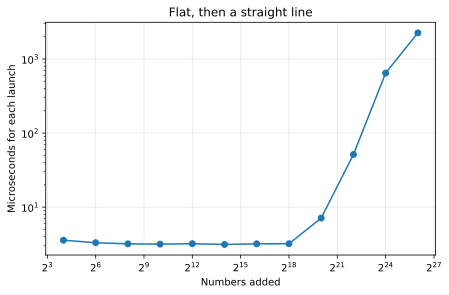

the smallest launch: 3.6 us, for 16 numbers
the largest launch:  2250 us, for 67,108,864 numbers


In [4]:
sizes = [2**power for power in range(4, 27, 2)]
times_us = []
for size in sizes:
  a, b = torch.rand(size, device='cuda'), torch.rand(size, device='cuda')
  out = torch.empty_like(a)
  times_us.append(1e3 * cudalib.bench_ms(lambda: extension.add(a, b, out), iters=100))

plt.figure(figsize=(7, 4.2))
plt.plot(sizes, times_us, 'o-')
plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Numbers added')
plt.ylabel('Microseconds for each launch')
plt.title('Flat, then a straight line')
plt.grid(alpha=.3)
plt.show()
print(f'the smallest launch: {times_us[0]:.1f} us, for {sizes[0]} numbers')
print(f'the largest launch:  {times_us[-1]:.0f} us, for {sizes[-1]:,} numbers')

The flat part on the left is the cost of a launch. It does not depend on the
work. On the right, the time grows with the bytes: the kernel is memory-bound.

A decode step of a real model launches about a thousand kernels, and most of
them are small. Part 5 measures what the flat part costs a server. It also
removes most of that cost with **CUDA graphs**. A CUDA graph records many
launches one time. Then it replays all of them with one call.

### Step 3: the threads of a warp read together

The 32 threads of a warp can read 32 numbers next to each other. Then the
memory system serves them with a small number of large reads. This is
**coalescing**. When each thread reads far from its neighbor, each thread
needs its own read.

Read numbers two ways: next to each other (stride 1), and 32 numbers apart
(stride 32). Compare the time for each number read.

The GPU keeps recent data in its **L2 cache**, a fast memory on the chip. A
test that reads a small array again and again measures the cache, not HBM. So
both reads here cover 512 MB, more than any L2 cache.

In [5]:
values = torch.rand(2**27, device='cuda')                   # 512 MB
ns_per_number = {}
for stride in (1, 32):
  num_reads = len(values) // stride
  out = torch.empty(num_reads, device='cuda')
  milliseconds = cudalib.bench_ms(lambda: extension.strided_read(values, out, stride), best_of=3)
  ns_per_number[stride] = 1e6 * milliseconds / num_reads
  print(f'stride {stride:>2}: {num_reads:>11,} numbers in {milliseconds:6.3f} ms '
        f'= {ns_per_number[stride]:.3f} ns for each number')
print(f'\neach number costs {ns_per_number[32] / ns_per_number[1]:.0f}x more with stride 32')

stride  1: 134,217,728 numbers in  2.795 ms = 0.021 ns for each number
stride 32:   4,194,304 numbers in  0.367 ms = 0.087 ns for each number

each number costs 4x more with stride 32


You can predict that ratio. The memory system moves data in pieces of 32
bytes: a **sector**.

- Stride 1: each number moves 4 bytes in and 4 bytes out. 8 bytes.
- Stride 32: each number needs its own sector. The kernel moves 32 bytes in,
  uses 4 of them, and moves 4 bytes out. 36 bytes.

36 / 8 = 4.5x. The number of bytes that you USE is not the number of bytes
that the memory system MOVES. Part 3 measures this in detail.

### What to remember from this notebook

- A **kernel** is the body of a loop. A **launch** runs it in many **threads**.
- Threads come in **thread blocks**, and all the blocks of a launch are the
  **grid**. The hardware runs 32 threads at a time: a **warp**.
- Each launch has a fixed cost. Many small kernels waste time.
- Neighbor threads must read neighbor addresses, or the memory system moves
  bytes that nobody uses.

Stage 08 of the ladder is the first kernel that you write for the engine. It
uses each word of this notebook.